# Hồ sơ cụm, khả năng diễn giải và ý nghĩa nghiệp vụ

Notebook này gán nhãn cụm cho toàn bộ khách hàng bằng cấu hình tốt nhất của cả ba
mô hình, xây dựng hồ sơ từng cụm trên thang giá trị RFM gốc, đo mức độ phân biệt
giữa các cụm, gán nhãn nghiệp vụ và so sánh khả năng diễn giải của ba thuật toán.

In [1]:
import sys
import warnings

sys.path.append('../src')

warnings.filterwarnings('ignore', category=RuntimeWarning)

import pandas as pd
from IPython.display import Image
from models.clustering import FEATURE_COLUMNS
from evaluation.stability import load_best_configs
from evaluation.cluster_interpretability import (
    MODEL_ORDER,
    SEGMENT_STRATEGY,
    fit_best_models,
    build_labeled_customers,
    cluster_z_means,
    build_cluster_profiles,
    separation_scores,
    build_separation_table,
    plot_rfm_bars,
    plot_radar,
    plot_pca_scatter,
    save_profiles,
)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

## 1. Chuẩn bị dữ liệu đầu vào

Bảng RFM gốc (`rfm_table.csv`) dùng để mô tả cụm bằng đơn vị mà bộ phận kinh doanh
đọc được: số ngày, số lần mua và số tiền. Bảng đã chuẩn hóa (`rfm_scaled.csv`) dùng
để huấn luyện mô hình và để tính mức độ phân biệt, vì phép đo đó cần ba đặc trưng
nằm trên cùng một thang.

In [2]:
rfm_raw = pd.read_csv('../data/processed/rfm_table.csv')
scaled = pd.read_csv('../data/processed/rfm_scaled.csv')
X = scaled[list(FEATURE_COLUMNS)].values

assert (rfm_raw['CustomerID'].values == scaled['CustomerID'].values).all(), 'Hai bảng không khớp thứ tự'
print(f'{len(rfm_raw)} khách hàng, hai bảng khớp nhau theo CustomerID')
rfm_raw.head()

4324 khách hàng, hai bảng khớp nhau theo CustomerID


,CustomerID,Recency,Frequency,Monetary
0,12347.0,2,7,4310.00
1,12348.0,75,4,1437.24
2,12349.0,18,1,1457.55
3,12350.0,310,1,294.40
4,12352.0,36,6,1265.41


Cấu hình tối ưu được đọc lại từ kết quả thực nghiệm của Task 12, giống cách làm ở
Task 13, để cả ba task luôn đánh giá đúng cùng một bộ cấu hình.

In [3]:
configs = load_best_configs('../outputs/results/clustering_experiments.csv')

print()
labels_by_model = fit_best_models(X, configs)

Loaded best configurations from ../outputs/results/clustering_experiments.csv (metric: silhouette)
  GMM     : {'n_components': 3, 'covariance_type': 'spherical'}
  HDBSCAN : {'min_cluster_size': 50, 'min_samples': None}
  K-Means : {'n_clusters': 3}

  K-Means : 3 cụm
  GMM     : 3 cụm
  HDBSCAN : 3 cụm, 854 điểm nhiễu


In [4]:
labeled = build_labeled_customers(rfm_raw, labels_by_model)
labeled.head()

,CustomerID,Recency,Frequency,Monetary,K-Means_Cluster,GMM_Cluster,HDBSCAN_Cluster
0,12347.0,2,7,4310.00,2,2,1
1,12348.0,75,4,1437.24,2,2,1
2,12349.0,18,1,1457.55,1,1,-1
3,12350.0,310,1,294.40,0,0,0
4,12352.0,36,6,1265.41,2,2,1


## 2. Xây dựng hồ sơ cụm khách hàng

Với mỗi cụm, hồ sơ gồm số lượng khách hàng, tỷ trọng, giá trị trung bình, trung vị
và độ lệch chuẩn của cả ba đặc trưng RFM. Bảng còn ghi thêm phần doanh thu mà cụm
đóng góp, vì tỷ trọng khách hàng và tỷ trọng doanh thu là hai con số rất khác nhau
và bộ phận kinh doanh cần cả hai.

In [5]:
profiles = build_cluster_profiles(labeled, X, labels_by_model)

profiles[['model', 'cluster', 'n_customers', 'share',
          'recency_mean', 'recency_median', 'recency_std',
          'frequency_mean', 'frequency_median', 'frequency_std',
          'monetary_mean', 'monetary_median', 'monetary_std']].round(2)

,model,cluster,n_customers,share,recency_mean,recency_median,recency_std,frequency_mean,frequency_median,frequency_std,monetary_mean,monetary_median,monetary_std
0,K-Means,0,990,0.23,254.31,252.0,64.70,1.39,1.0,0.77,400.67,282.41,518.41
1,K-Means,1,2024,0.47,54.05,45.0,41.14,2.04,2.0,1.04,601.27,501.42,477.74
2,K-Means,2,1310,0.30,29.13,17.0,36.23,9.76,7.0,11.95,5114.37,2498.04,14597.45
3,GMM,0,923,0.21,260.17,257.0,63.01,1.33,1.0,0.72,371.72,266.45,401.92
4,GMM,1,2098,0.49,56.94,46.0,44.54,2.05,2.0,1.04,597.61,501.13,446.67
5,GMM,2,1303,0.30,30.49,17.0,39.39,9.78,7.0,11.98,5154.71,2526.23,14631.84
6,HDBSCAN,-1,854,0.20,130.18,123.5,102.87,7.76,3.0,15.14,5260.13,1056.15,18153.62
7,HDBSCAN,0,1386,0.32,154.05,128.0,115.57,1.00,1.0,0.00,302.82,251.81,206.23
8,HDBSCAN,1,1502,0.35,28.40,21.0,26.69,6.06,5.0,3.56,2035.47,1572.78,1507.95
9,HDBSCAN,2,582,0.13,54.95,39.0,49.20,2.00,2.0,0.00,591.65,558.49,286.10


In [6]:
profiles[['model', 'cluster', 'n_customers', 'share', 'revenue', 'revenue_share']].round(4)

,model,cluster,n_customers,share,revenue,revenue_share
0,K-Means,0,990,0.2290,396664.111,0.0477
1,K-Means,1,2024,0.4681,1216979.622,0.1464
2,K-Means,2,1310,0.3030,6699823.960,0.8059
3,GMM,0,923,0.2135,343094.061,0.0413
4,GMM,1,2098,0.4852,1253779.992,0.1508
5,GMM,2,1303,0.3013,6716593.640,0.8079
6,HDBSCAN,-1,854,0.1975,4492154.451,0.5403
7,HDBSCAN,0,1386,0.3205,419705.141,0.0505
8,HDBSCAN,1,1502,0.3474,3057269.921,0.3677
9,HDBSCAN,2,582,0.1346,344338.180,0.0414


## 3. Đánh giá khả năng diễn giải của cụm

### 3.1. Sự khác biệt về đặc trưng RFM giữa các cụm

Giá trị trung bình của từng đặc trưng đã chuẩn hóa, theo từng cụm. Vì dữ liệu đã
qua StandardScaler nên số 0 là mức trung bình toàn bộ khách hàng, và giá trị đọc
trực tiếp được theo đơn vị độ lệch chuẩn.

In [7]:
for model_name in MODEL_ORDER:
    print(f'--- {model_name}')
    print(cluster_z_means(X, labels_by_model[model_name]).round(3).to_string())
    print()

--- K-Means
         Recency  Frequency  Monetary
cluster                              
0          1.616     -0.744    -0.768
1         -0.382     -0.419    -0.349
2         -0.631      1.209     1.120

--- GMM
         Recency  Frequency  Monetary
cluster                              
0          1.674     -0.773    -0.809
1         -0.353     -0.412    -0.345
2         -0.617      1.210     1.129

--- HDBSCAN
         Recency  Frequency  Monetary
cluster                              
-1         0.377      0.453     0.360
 0         0.615     -0.951    -0.833
 1        -0.638      0.758     0.655
 2        -0.373     -0.355    -0.234



### 3.2. Mức độ phân biệt của cụm

$$\Delta_j = \frac{\max_k(\bar{x}_{kj}) - \min_k(\bar{x}_{kj})}{\sigma_j}$$

`sigma_j` là độ lệch chuẩn của toàn bộ dữ liệu. Trên dữ liệu đã chuẩn hóa,
`sigma_j` bằng 1 nên `delta_j` chính là khoảng cách giữa cụm cao nhất và cụm thấp
nhất, tính theo số độ lệch chuẩn. Các điểm nhiễu của HDBSCAN không tham gia phép
tính vì nhiễu không phải một cụm.

In [8]:
separation = build_separation_table(X, labels_by_model)
separation.round(3)

,model,delta_recency,delta_frequency,delta_monetary,delta_mean,delta_min
0,K-Means,2.246,1.953,1.888,2.029,1.888
1,GMM,2.291,1.983,1.939,2.071,1.939
2,HDBSCAN,1.253,1.708,1.487,1.483,1.253


## 4. Đánh giá ý nghĩa nghiệp vụ của cụm

Nhãn nghiệp vụ được gán bằng quy tắc trên z-score trung bình của cụm chứ không gán
tay, để cùng một hồ sơ hành vi luôn nhận cùng một tên ở cả ba mô hình. Trục giá trị
`value_z` là trung bình của Frequency và Monetary; Recency giữ nguyên chiều nên
giá trị càng lớn nghĩa là càng lâu chưa mua.

In [9]:
profiles[['model', 'cluster', 'segment', 'n_customers', 'share', 'revenue_share',
          'recency_z', 'frequency_z', 'monetary_z']].round(3)

,model,cluster,segment,n_customers,share,revenue_share,recency_z,frequency_z,monetary_z
0,K-Means,0,Khách hàng đã rời bỏ,990,0.229,0.048,1.616,-0.744,-0.768
1,K-Means,1,Khách hàng phổ thông,2024,0.468,0.146,-0.382,-0.419,-0.349
2,K-Means,2,Khách hàng giá trị cao,1310,0.303,0.806,-0.631,1.209,1.120
3,GMM,0,Khách hàng đã rời bỏ,923,0.213,0.041,1.674,-0.773,-0.809
4,GMM,1,Khách hàng phổ thông,2098,0.485,0.151,-0.353,-0.412,-0.345
5,GMM,2,Khách hàng giá trị cao,1303,0.301,0.808,-0.617,1.210,1.129
6,HDBSCAN,-1,Chưa phân khúc (nhiễu),854,0.198,0.540,0.377,0.453,0.360
7,HDBSCAN,0,Khách hàng đã rời bỏ,1386,0.321,0.050,0.615,-0.951,-0.833
8,HDBSCAN,1,Khách hàng giá trị cao,1502,0.347,0.368,-0.638,0.758,0.655
9,HDBSCAN,2,Khách hàng phổ thông,582,0.135,0.041,-0.373,-0.355,-0.234


In [10]:
pd.DataFrame(SEGMENT_STRATEGY.items(), columns=['Phân khúc', 'Chiến lược chăm sóc'])

,Phân khúc,Chiến lược chăm sóc
0,Khách hàng giá trị cao,"Giữ chân: ưu đãi riêng, chăm sóc chủ động, ưu ..."
1,Khách hàng phổ thông,"Tăng giá trị: gợi ý mua kèm, chương trình tích..."
2,Khách hàng đã rời bỏ,"Kích hoạt lại: chiến dịch win-back, hoặc loại ..."
3,Khách hàng giá trị cao có nguy cơ rời bỏ,Cảnh báo sớm: liên hệ trực tiếp trước khi mất hẳn
4,Chưa phân khúc (nhiễu),Không áp dụng được chính sách: cần xử lý riêng...


## 5. Trực quan hóa kết quả phân cụm

Ba biểu đồ dùng chung một quy ước màu: màu gắn với **phân khúc nghiệp vụ**, không
gắn với số hiệu cụm. Số hiệu cụm do thuật toán tự sinh nên cụm 2 của K-Means và cụm
1 của HDBSCAN có thể cùng là nhóm giá trị cao; nếu tô theo số hiệu thì ba biểu đồ
sẽ không so sánh được với nhau. Nhiễu dùng màu xám vì đó không phải một phân khúc.

Saved figure to ../outputs/figures/cluster_rfm_bars.png


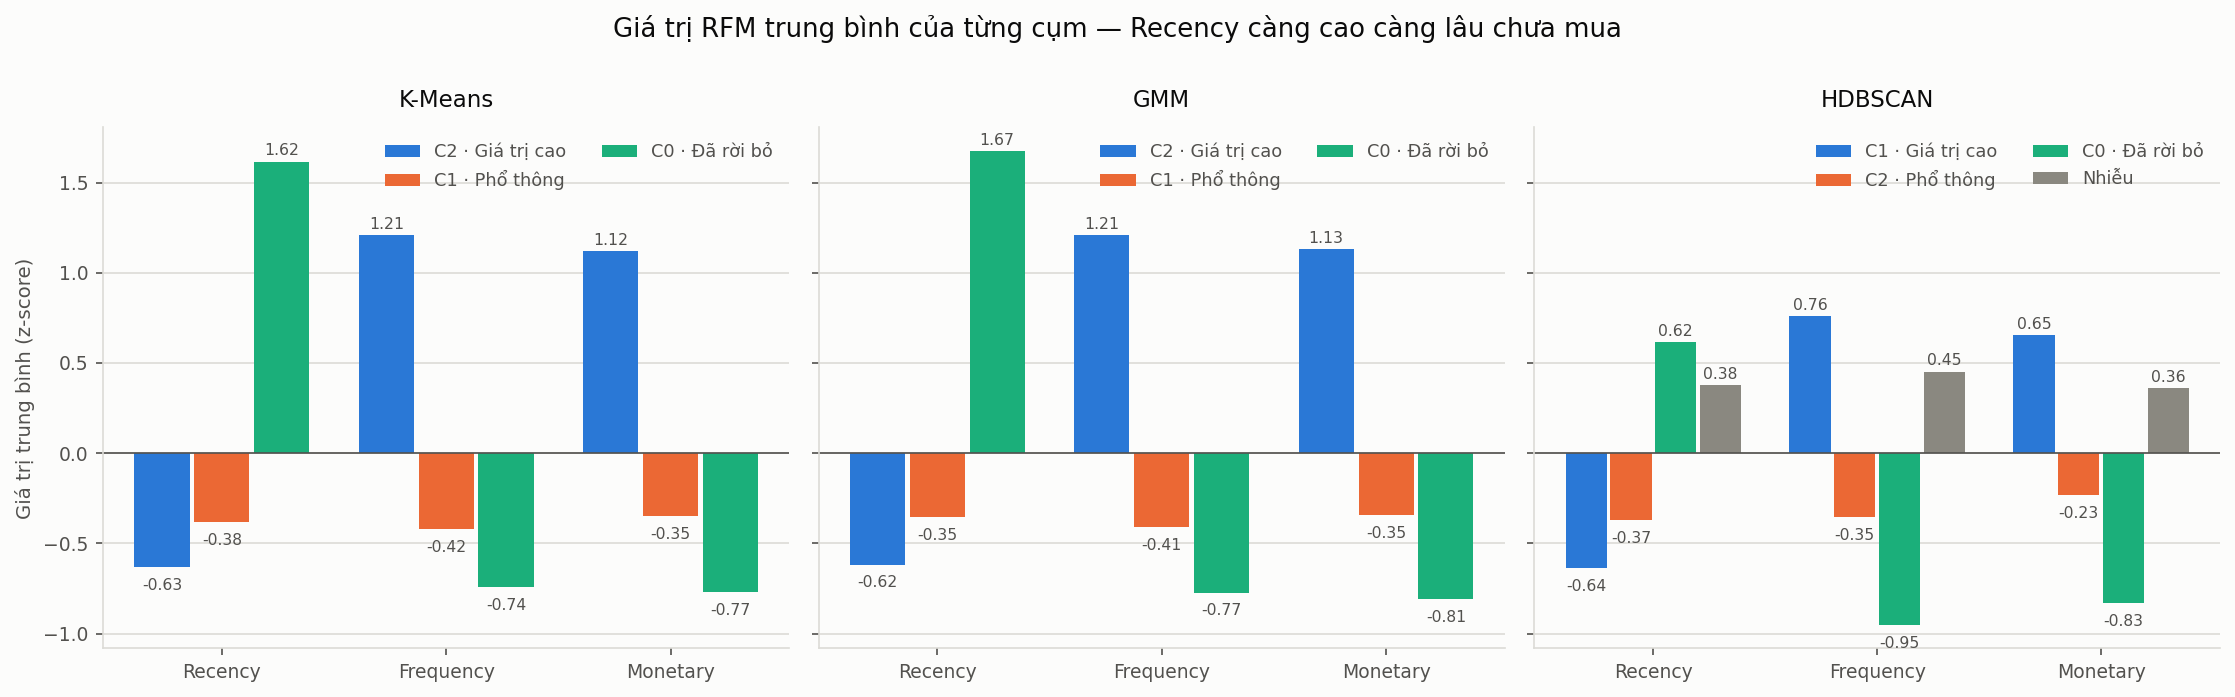

In [11]:
Image(plot_rfm_bars(X, labels_by_model, '../outputs/figures/cluster_rfm_bars.png'))

Saved figure to ../outputs/figures/cluster_radar.png


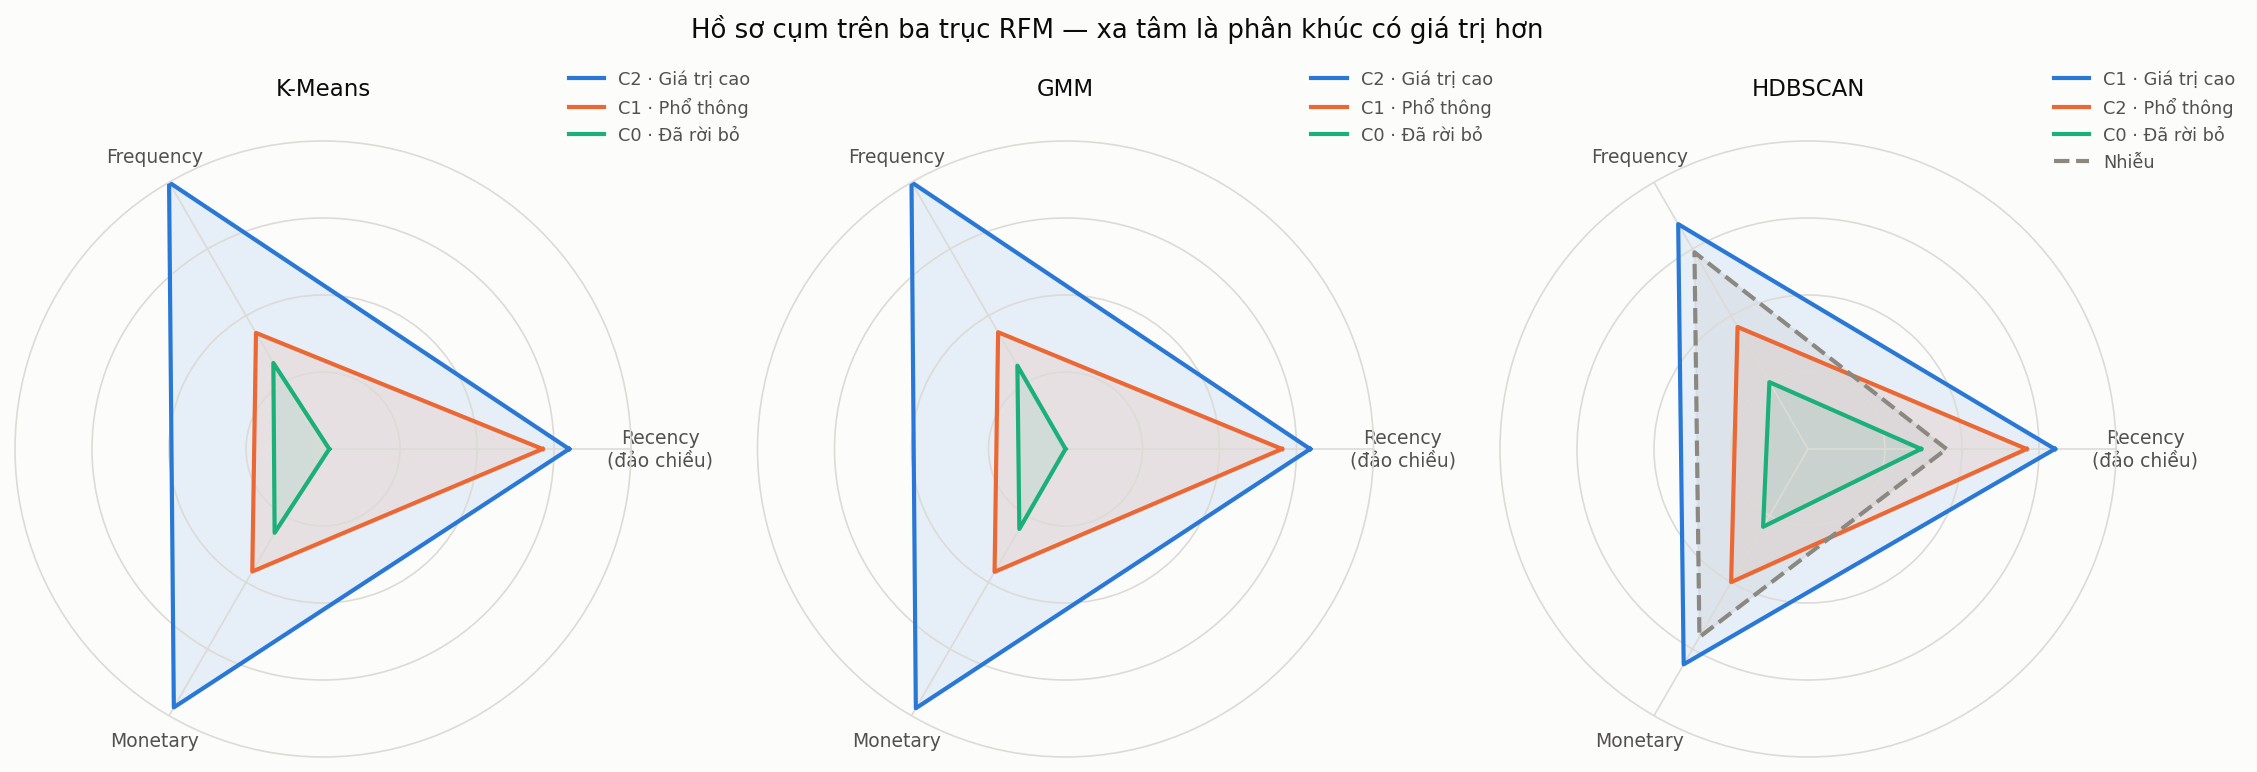

In [12]:
Image(plot_radar(X, labels_by_model, '../outputs/figures/cluster_radar.png'))

Saved figure to ../outputs/figures/cluster_pca.png


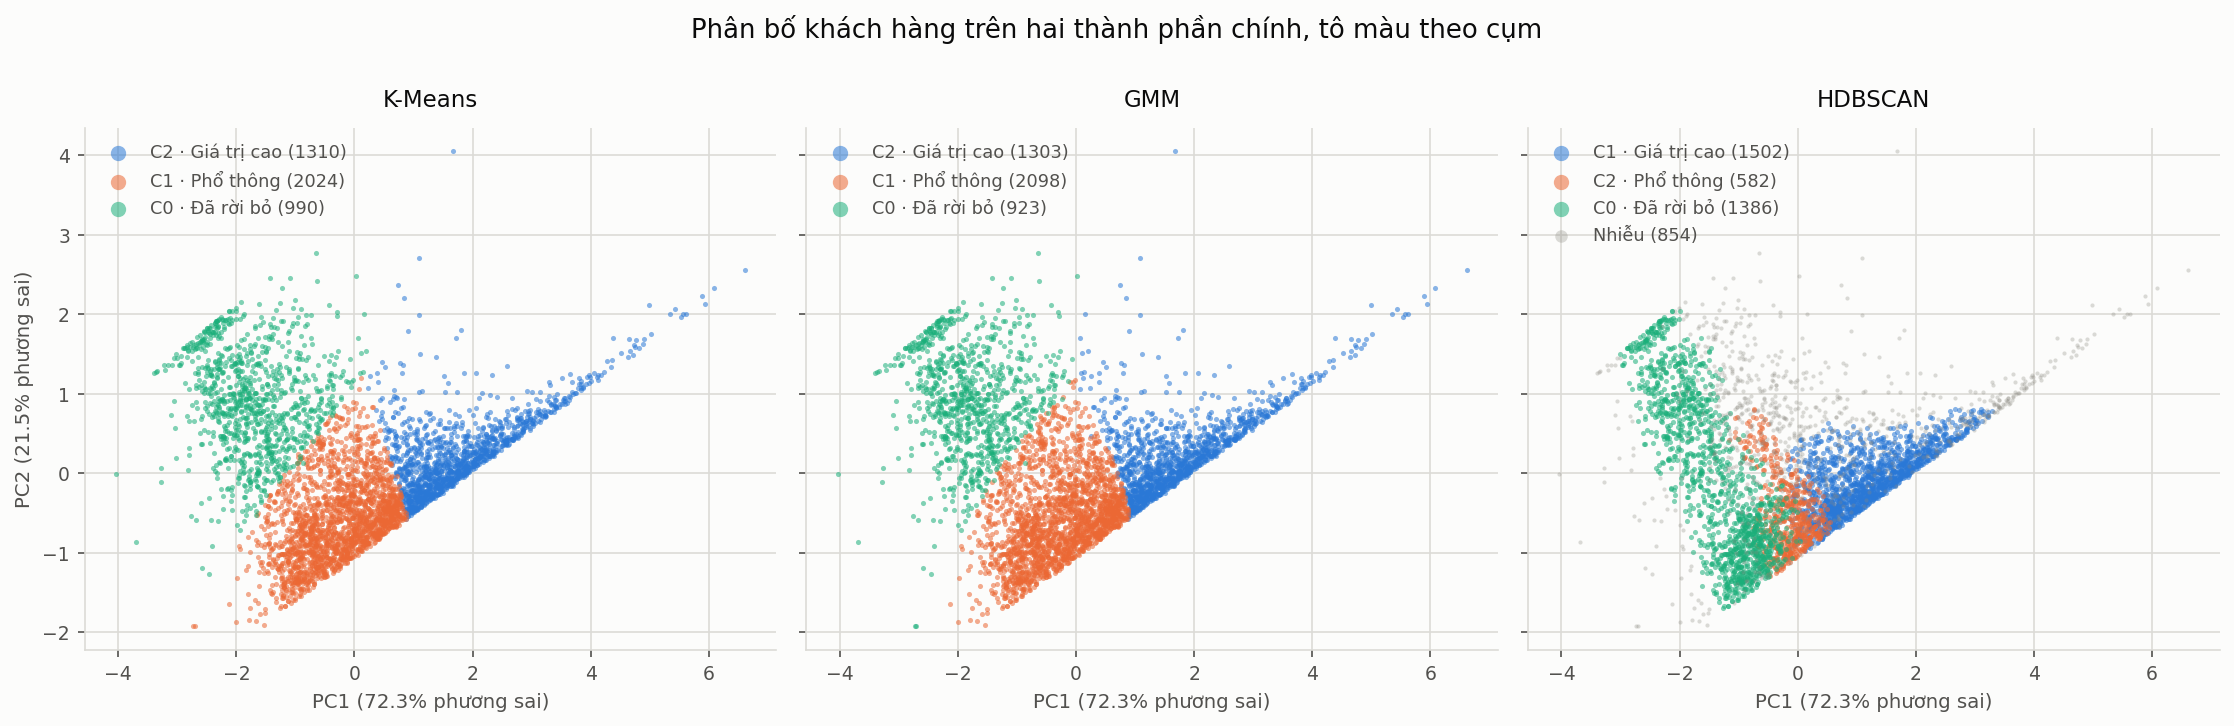

In [13]:
Image(plot_pca_scatter(X, labels_by_model, '../outputs/figures/cluster_pca.png'))

## 6. So sánh khả năng diễn giải giữa các thuật toán

Bảng dưới ghép ba nhóm tiêu chí: mức độ phân biệt của đặc trưng, số phân khúc đặt
tên được, và tỷ lệ khách hàng thực sự được xếp vào một phân khúc.

In [14]:
named = profiles[profiles['segment'] != 'Chưa phân khúc (nhiễu)']

comparison = (
    separation.set_index('model')[['delta_mean', 'delta_min']]
    .join(named.groupby('model').agg(
        n_segments=('segment', 'nunique'),
        covered_customers=('n_customers', 'sum'),
        covered_revenue_share=('revenue_share', 'sum'),
    ))
    .assign(coverage=lambda d: d['covered_customers'] / len(labeled))
    .loc[list(MODEL_ORDER)]
)
comparison.round(3)

,delta_mean,delta_min,n_segments,covered_customers,covered_revenue_share,coverage
model,,,,,,
K-Means,2.029,1.888,3,4324,1.00,1.000
GMM,2.071,1.939,3,4324,1.00,1.000
HDBSCAN,1.483,1.253,3,3470,0.46,0.802


Kiểm tra riêng nhóm nhiễu của HDBSCAN: đây là nhóm khách hàng không được gán phân
khúc nào, nên cần biết chính xác đó là những ai trước khi kết luận về ý nghĩa
nghiệp vụ của mô hình.

In [15]:
noise = profiles[profiles['segment'] == 'Chưa phân khúc (nhiễu)']

print(noise[['n_customers', 'share', 'revenue', 'revenue_share',
             'recency_mean', 'frequency_mean',
             'monetary_mean', 'monetary_median', 'monetary_std']].round(2).to_string(index=False))

 n_customers  share    revenue  revenue_share  recency_mean  frequency_mean  monetary_mean  monetary_median  monetary_std
         854    0.2 4492154.45           0.54        130.18            7.76        5260.13          1056.15      18153.62


## 7. Lưu kết quả

In [16]:
labeled.to_csv('../data/processed/customer_clusters_all_models.csv', index=False)
save_profiles(profiles, '../data/processed/cluster_profiles.csv')
separation.to_csv('../outputs/results/cluster_separation.csv', index=False)
print('Saved separation scores to ../outputs/results/cluster_separation.csv')

Saved 10 cluster profiles to ../data/processed/cluster_profiles.csv
Saved separation scores to ../outputs/results/cluster_separation.csv
